<a href="https://colab.research.google.com/github/abdul-rafey7016/24I-2589/blob/main/LAB04/i242589_lab04_DAV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [66]:
import pandas as pd
import numpy as numpy
import seaborn as sns
import matplotlib.pyplot as plt
df= pd.read_csv("Sample - Superstore.csv",encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


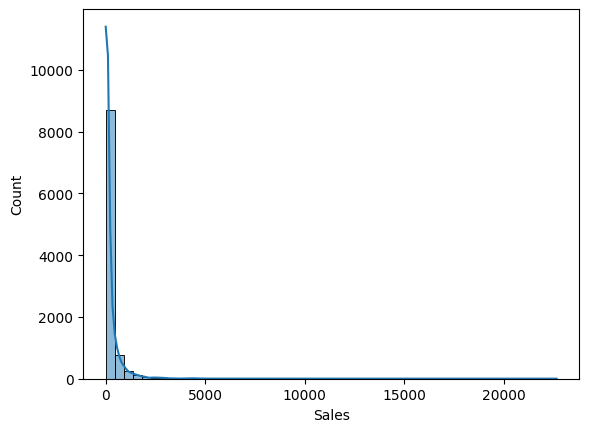

Mean  229.85800083049833 
Median  54.489999999999995 
Skewness 12.97275234181623
the data is highly right skewed because mean>meadian and in graph bar is on left side


In [67]:
#task1
sns.histplot(df['Sales'],kde=True,bins=50)
plt.show()
#
print('Mean ',df["Sales"].mean(),'\nMedian ',df["Sales"].median(),'\nSkewness',df["Sales"].skew())
print('the data is highly right skewed because mean>meadian and in graph bar is on left side')

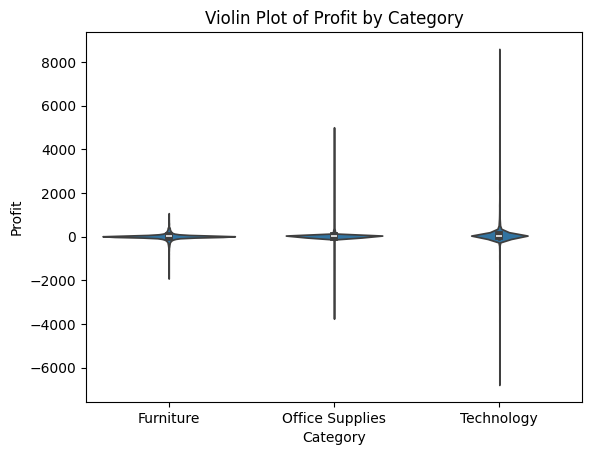

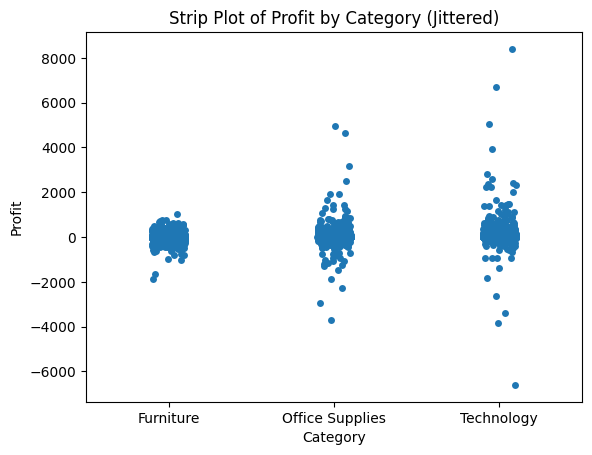

The strip plot shows individual data point telling us more about spread and shape of dataset and Voilin plot hides data when data is large


In [68]:

sns.violinplot(x='Category', y='Profit', data=df)
plt.title('Violin Plot of Profit by Category')
plt.show()
sns.stripplot(x='Category', y='Profit', data=df, jitter=True)
plt.title('Strip Plot of Profit by Category (Jittered)')

plt.show()
print('The strip plot shows individual data point telling us more about spread and shape of dataset and Voilin plot hides data when data is large')

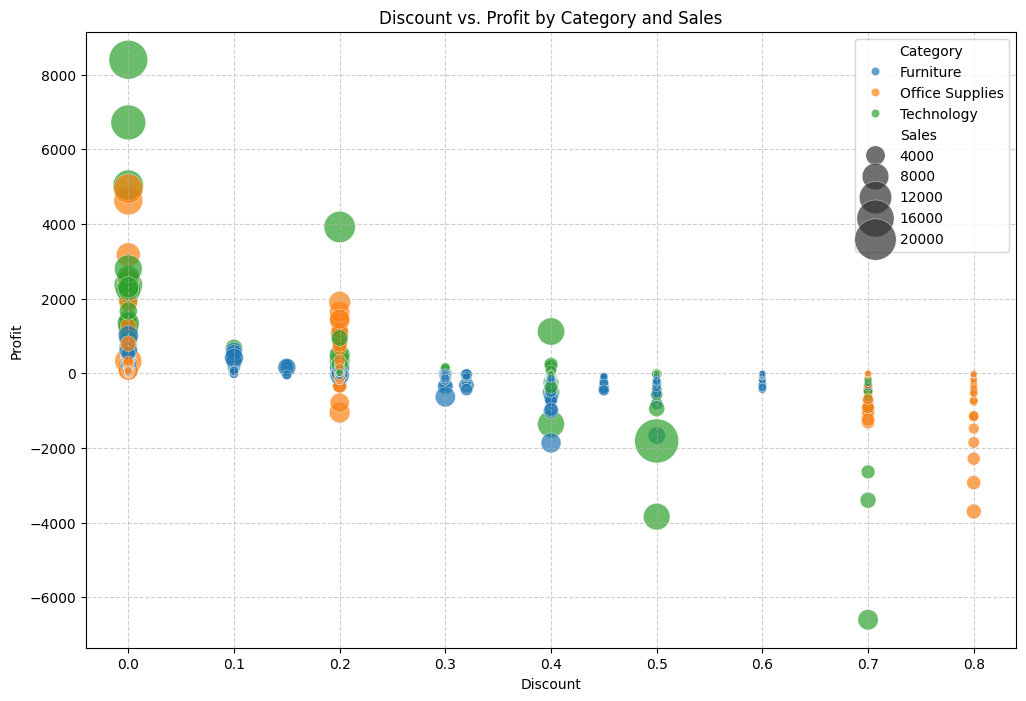

In [69]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', size='Sales', sizes=(20, 1000), alpha=0.7)
plt.title('Discount vs. Profit by Category and Sales')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [70]:
print('Correlation in pearson')
display(df.select_dtypes(include='number').corr(method="pearson"))
print('Correlation in spearman')
display(df.select_dtypes(include='number').corr(method="spearman"))
print('The relation in quantity and profit is higher in spearman correlation as compared to pearson')

Correlation in pearson


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
Row ID,1.000000,0.009671,-0.001359,-0.004016,0.013480,0.012497
Postal Code,0.009671,1.000000,-0.023854,0.012761,0.058443,-0.029961
Sales,-0.001359,-0.023854,1.000000,0.200795,-0.028190,0.479064
Quantity,-0.004016,0.012761,0.200795,1.000000,0.008623,0.066253
Discount,0.013480,0.058443,-0.028190,0.008623,1.000000,-0.219487
Profit,0.012497,-0.029961,0.479064,0.066253,-0.219487,1.000000


Correlation in spearman


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
Row ID,1.000000,0.011466,-0.001310,-0.002416,0.012655,-0.010545
Postal Code,0.011466,1.000000,-0.002059,0.013952,0.052793,-0.005451
Sales,-0.001310,-0.002059,1.000000,0.327426,-0.056969,0.518407
Quantity,-0.002416,0.013952,0.327426,1.000000,-0.000878,0.234491
Discount,0.012655,0.052793,-0.056969,-0.000878,1.000000,-0.543350
Profit,-0.010545,-0.005451,0.518407,0.234491,-0.543350,1.000000


The relation in quantity and profit is higher in spearman correlation as compared to pearson


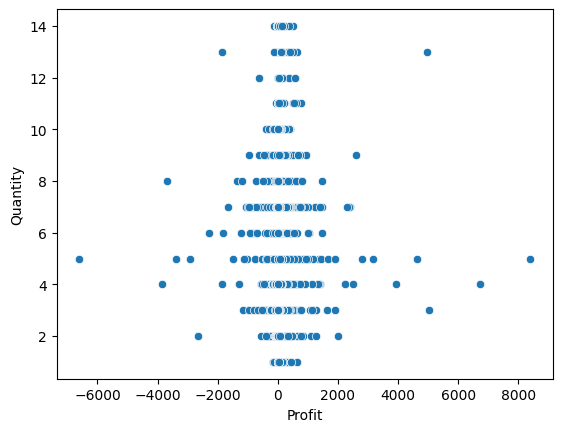

In [71]:
sns.scatterplot(data=df,y='Quantity',x='Profit')
plt.show()

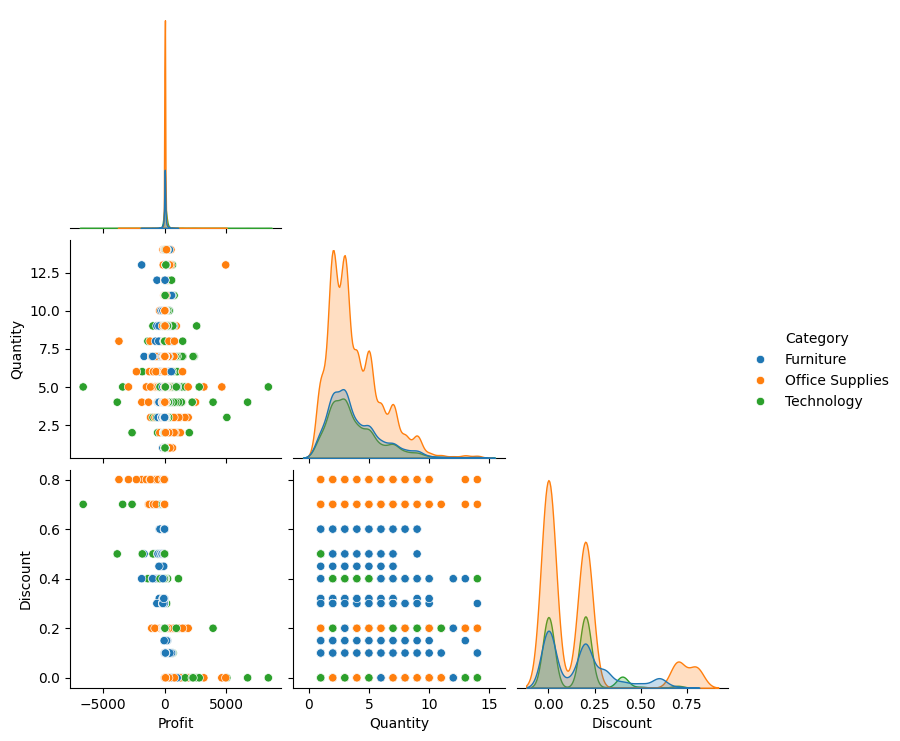

profit is not causation to only quantity only it depends on the discount too so we cannot explain it through quatity only


In [65]:
sns.pairplot(df,vars=['Profit','Quantity','Discount'],hue='Category',corner=True)
plt.show()
print('profit is not causation to only quantity only it depends on the discount too so we cannot explain it through quatity only')

Category,Furniture,Office Supplies,Technology,All
Region,,,,
Central,163797.1638,167026.415,170416.312,5.012399e+05
East,208291.2040,205516.055,264973.981,6.787812e+05
South,117298.6840,125651.313,148771.908,3.917219e+05
West,252612.7435,220853.249,251991.832,7.254578e+05
All,741999.7953,719047.032,836154.033,2.297201e+06


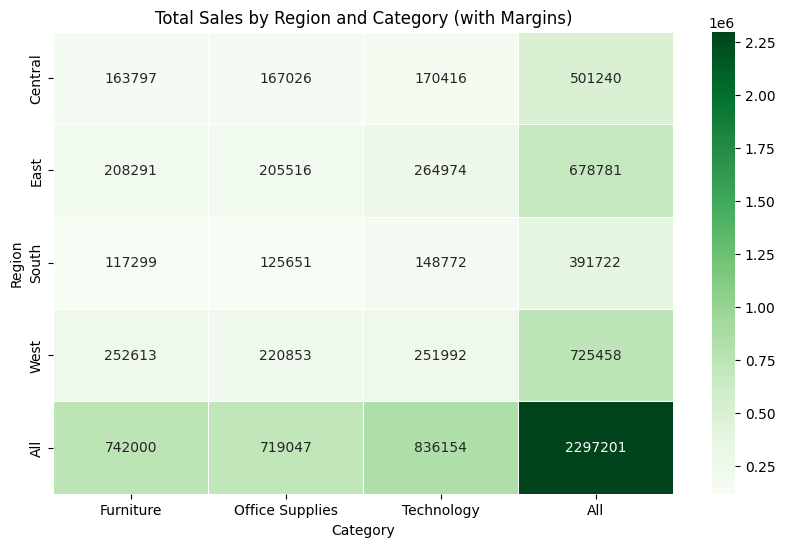

The region-category combination that contributes most to overall revenue is East - Technology with total sales of 264,973.98.


In [72]:
sales_pivot = df.pivot_table(index='Region', columns='Category', values='Sales', aggfunc='sum', margins=True)
display(sales_pivot)

plt.figure(figsize=(10, 6))
sns.heatmap(sales_pivot, annot=True, fmt='.0f', cmap='Greens', linewidths=.5)
plt.title('Total Sales by Region and Category (with Margins)')
plt.show()

max_sales_combination = sales_pivot.drop('All', axis=0).drop('All', axis=1).stack().idxmax()
max_sales_value = sales_pivot.drop('All', axis=0).drop('All', axis=1).stack().max()

print(f"The region-category combination that contributes most to overall revenue is {max_sales_combination[0]} - {max_sales_combination[1]} with total sales of {max_sales_value:,.2f}.")

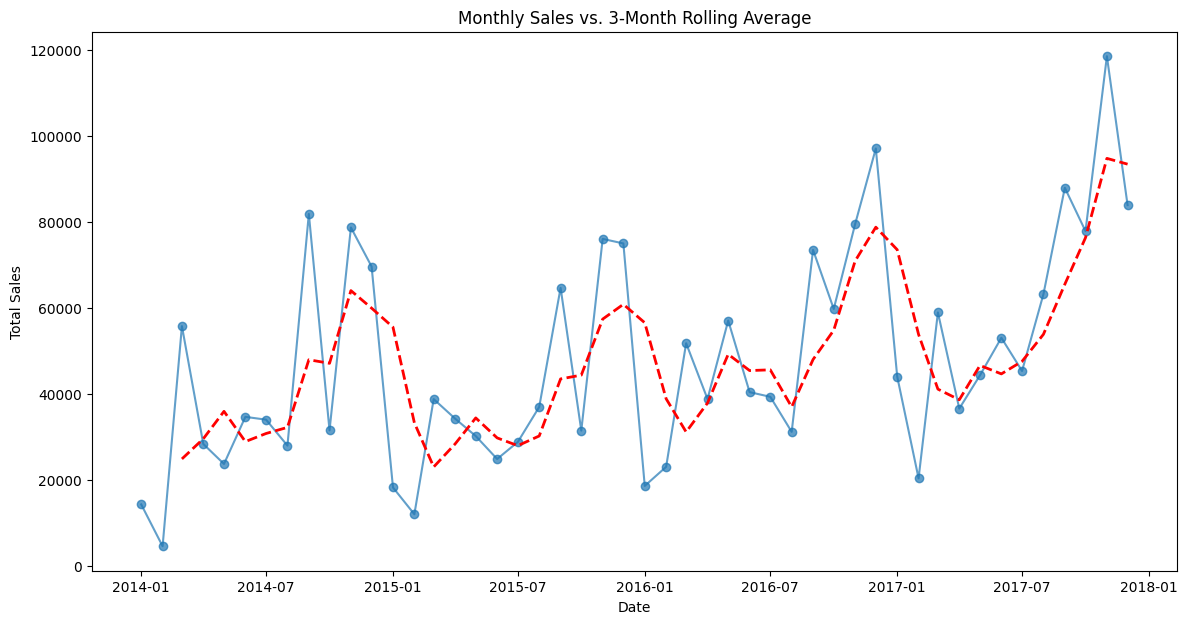

In [73]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df_time_series = df.set_index('Order Date')

monthly_sales = df_time_series['Sales'].resample('MS').sum()

rolling_avg = monthly_sales.rolling(window=3).mean()

plt.figure(figsize=(14, 7))
plt.plot(monthly_sales.index, monthly_sales.values, label='Monthly Sales', marker='o', linestyle='-', alpha=0.7)
plt.plot(rolling_avg.index, rolling_avg.values, label='3-Month Rolling Average', color='red', linestyle='--', linewidth=2)
plt.title('Monthly Sales vs. 3-Month Rolling Average')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

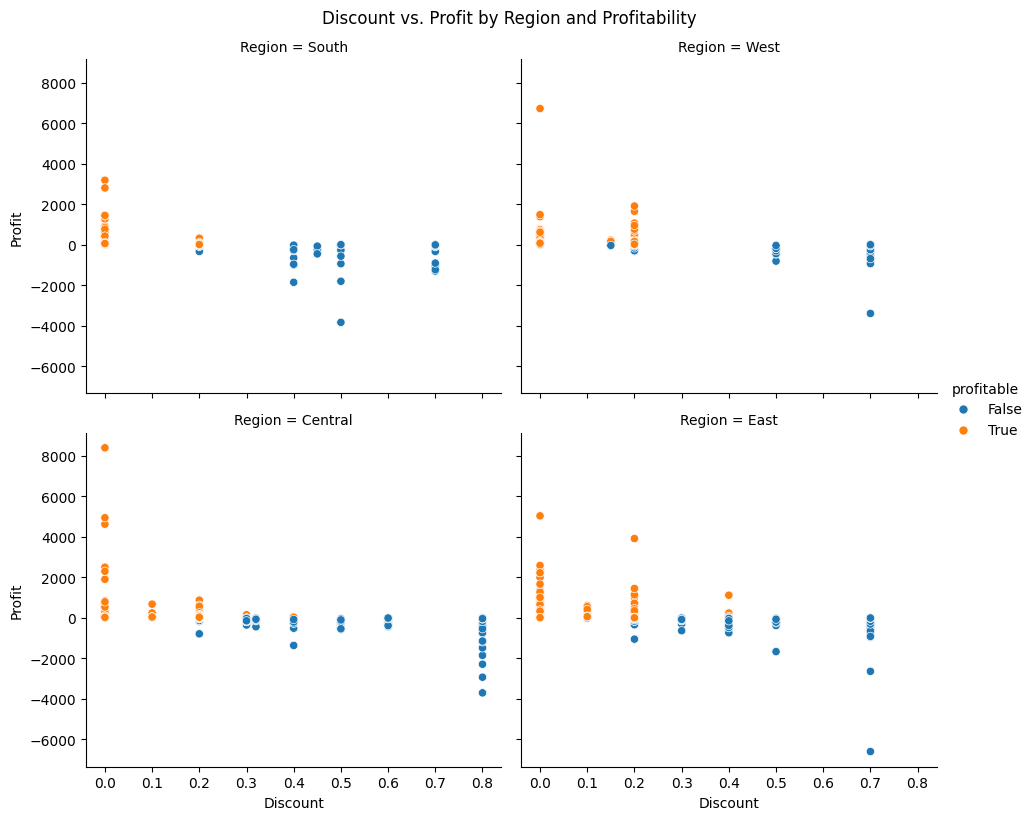

In [74]:
df['profitable'] = df['Profit'] > 0

sns.relplot(data=df, x='Discount', y='Profit', col='Region', hue='profitable', kind='scatter', col_wrap=2, height=4, aspect=1.2)
plt.suptitle('Discount vs. Profit by Region and Profitability', y=1.02)
plt.show()

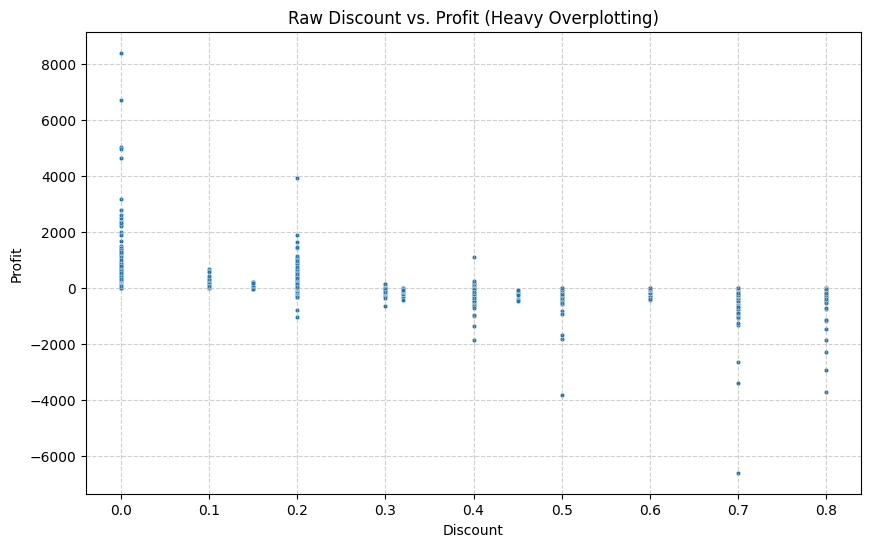

In [75]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Discount', y='Profit', s=10)
plt.title('Raw Discount vs. Profit (Heavy Overplotting)')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

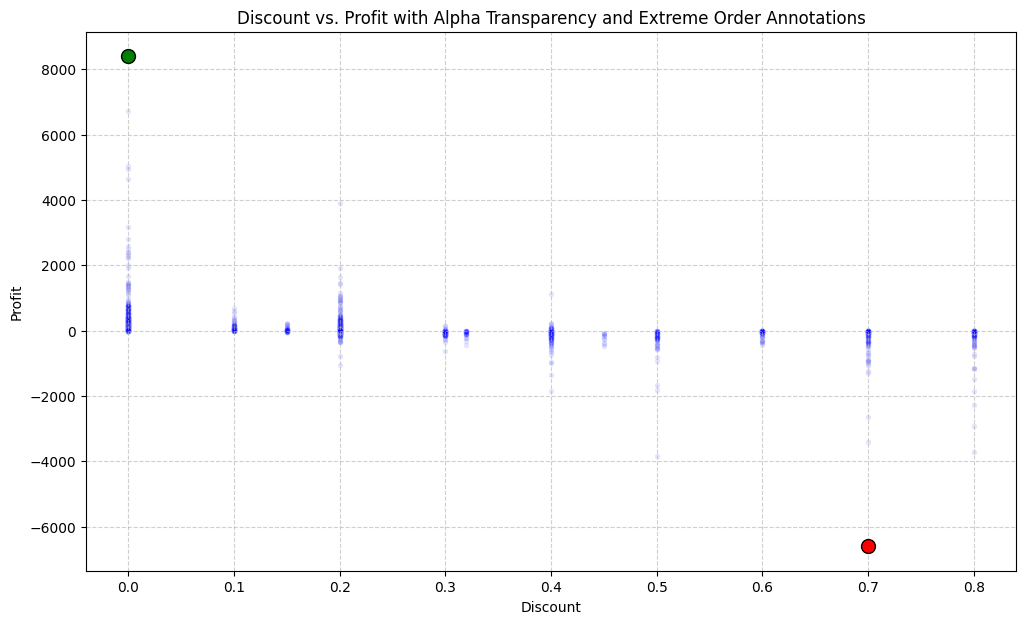

In [76]:

most_profitable_order = df.loc[df['Profit'].idxmax()]
largest_loss_order = df.loc[df['Profit'].idxmin()]

plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='Discount', y='Profit', alpha=0.1, s=15, color='blue') # Use alpha for transparency

plt.scatter(most_profitable_order['Discount'], most_profitable_order['Profit'], color='green', s=100, edgecolors='black', zorder=5)
plt.scatter(largest_loss_order['Discount'], largest_loss_order['Profit'], color='red', s=100, edgecolors='black', zorder=5)

plt.title('Discount vs. Profit with Alpha Transparency and Extreme Order Annotations')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()